# Testing
### Anteil Ausländer*innen
#### Beschreibung
Anteil Ausländer*innen der Stadt Zürich nach Jahr.

INT: https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_anteil_auslaenderinnen_jahr_od3226

PROD: https://data.stadt-zuerich.ch/dataset/bev_anteil_auslaenderinnen_jahr_od3226

Datum: 02.03.2026


### Importiere die notwendigen Packages

In [83]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [84]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [85]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [86]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [87]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

Definiere Settings. Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen), 

In [88]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [89]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln

In [90]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [91]:
#speichere die variable global, damit ich sie später verwenden kann, wenn ich grafiken mit diesem namen speichere.
package_name = "bev_anteil_auslaenderinnen_jahr_od3226"

In [92]:
data2betested = mypy_dl.load_data(
    status = 'prod'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BEV322OD3226"    
    , datums_attr = ['StichtagDatJahr']
    )

fp lautet:https://data.stadt-zuerich.ch/dataset/bev_anteil_auslaenderinnen_jahr_od3226/download/BEV322OD3226.csv


 **Überprüfe die Metadaten:**

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_anteil_auslaenderinnen_jahr_od3226 

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/bev_anteil_auslaenderinnen_jahr_od3226 

data_source: web


In [93]:
data2betested.head(2)

,StichtagDatJahr,DatenstandCd,HerkunftCd,HerkunftLang,AuslAnt
0,1901-01-01,D,2,Ausländer*in,28
1,1902-01-01,D,2,Ausländer*in,28


Berechne weitere Attribute falls notwendig

In [94]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_str = lambda x: x.Jahr.astype(str),
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('Jahr', ascending=False)
    )
data2betested.dtypes

StichtagDatJahr    datetime64[ns]
DatenstandCd               object
HerkunftCd                  int64
HerkunftLang               object
AuslAnt                   float64
Jahr               datetime64[ns]
Jahr_str                   object
Jahr_nbr                    int32
dtype: object

Minimales und maximales Jahr im Datensatz

In [95]:
data_max_date = str(max(data2betested.Jahr).year)
data_min_date = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1901 und ein Maximumjahr von 2024


### Einfache Datentests

In [96]:
data2betested.head(2).T

,123,122
StichtagDatJahr,2024-01-01 00:00:00,2023-01-01 00:00:00
DatenstandCd,D,V
HerkunftCd,2,2
HerkunftLang,Ausländer*in,Ausländer*in
AuslAnt,34,34
Jahr,2024-01-01 00:00:00,2023-01-01 00:00:00
Jahr_str,2024-01-01,2023-01-01
Jahr_nbr,2024,2023


In [97]:
data2betested.shape

(124, 8)

Beschreibe einzelne Attribute

In [98]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 124 entries, 123 to 0
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   StichtagDatJahr  124 non-null    datetime64[ns]
 1   DatenstandCd     124 non-null    object        
 2   HerkunftCd       124 non-null    int64         
 3   HerkunftLang     124 non-null    object        
 4   AuslAnt          124 non-null    float64       
 5   Jahr             124 non-null    datetime64[ns]
 6   Jahr_str         124 non-null    object        
 7   Jahr_nbr         124 non-null    int32         
dtypes: datetime64[ns](2), float64(1), int32(1), int64(1), object(3)
memory usage: 33.4 KB


In [99]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 124 rows (observations) and 8 columns (variables).
There seem to be 0 exact duplicates in the data.


Welches sind die Quartiere ohne Werte bei AnzBestWir?

In [100]:
data2betested[np.isnan(data2betested.AuslAnt)].head()

,StichtagDatJahr,DatenstandCd,HerkunftCd,HerkunftLang,AuslAnt,Jahr,Jahr_str,Jahr_nbr


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [101]:
data2betested = data2betested.set_index("Jahr")
data2betested = data2betested.sort_index()

In [102]:
#data2betested.info()
data2betested.index.year.unique()

Index([1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909, 1910,
       ...
       2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
      dtype='int32', name='Jahr', length=124)

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [103]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number',datetime_is_numeric=True))
except:
    print("No categorical data in dataset.")

No categorical data in dataset.


Beschreibe numerische Attribute

In [104]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,HerkunftCd,AuslAnt,Jahr_nbr
count,124,124,124
mean,2,21,"1,962"
std,0,9,36
min,2,7,"1,901"
25%,2,15,"1,932"
50%,2,20,"1,962"
75%,2,30,"1,993"
max,2,34,"2,024"


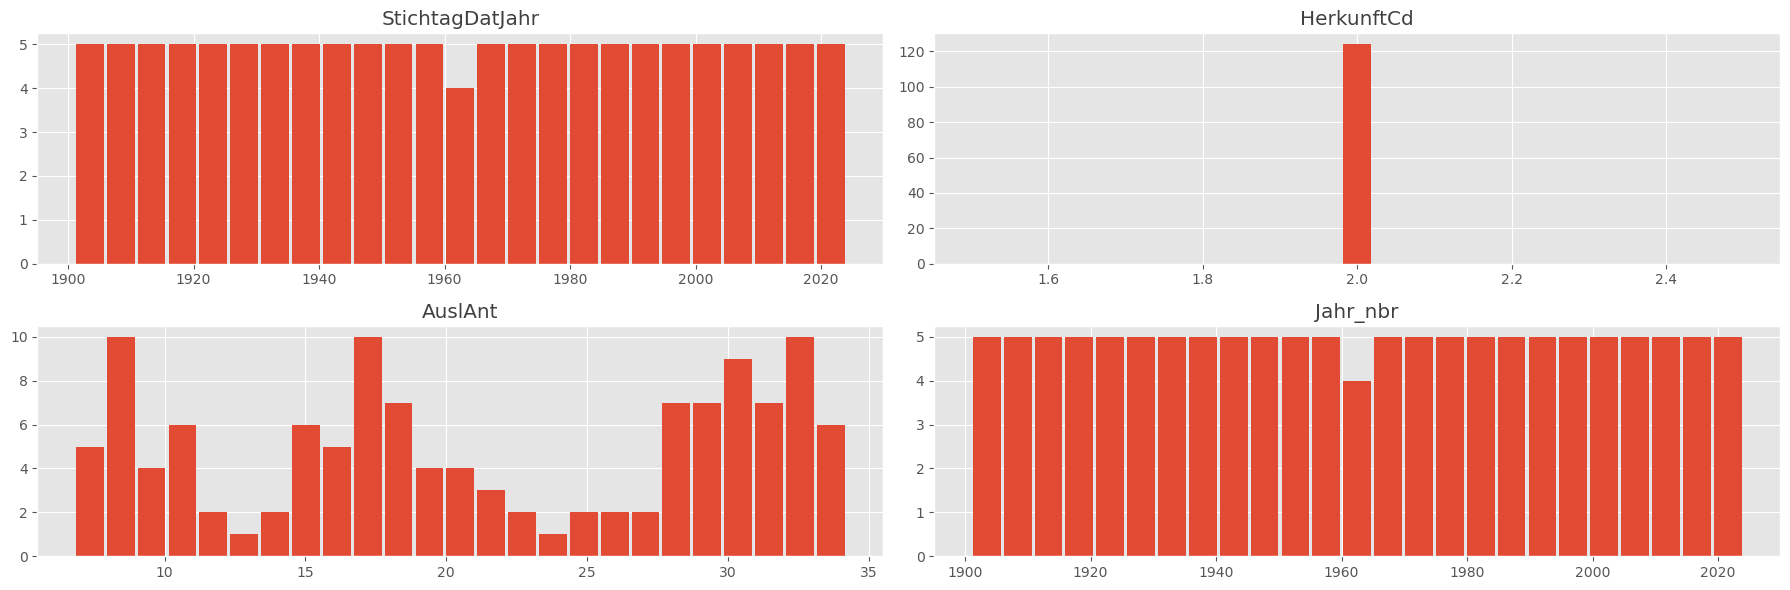

In [105]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [106]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,StichtagDatJahr,DatenstandCd,HerkunftCd,HerkunftLang,AuslAnt,Jahr_str,Jahr_nbr
Jahr,,,,,,,


### Nullwerte und Missings?

In [107]:
data2betested.isnull().sum()

StichtagDatJahr    0
DatenstandCd       0
HerkunftCd         0
HerkunftLang       0
AuslAnt            0
Jahr_str           0
Jahr_nbr           0
dtype: int64

### Gruppierungen

In [108]:
agg_jahr = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr']) \
    .agg(sum_AuslAnt=('AuslAnt', 'sum')) \
    .sort_values('Jahr', ascending=False) 
agg_jahr.reset_index().head(3)

,Jahr,sum_AuslAnt
0,2024-01-01,34
1,2023-01-01,34
2,2022-01-01,33


In [109]:
data2betested.columns

Index(['StichtagDatJahr', 'DatenstandCd', 'HerkunftCd', 'HerkunftLang', 'AuslAnt', 'Jahr_str',
       'Jahr_nbr'],
      dtype='object')

### Zeitpunkte und Zeiträume abfragen

A particular powerful feature of the Pandas DataFrame is its indexing capability that also works using time-based entities, such as dates and times. We have already created the index above, so let's put it to use.

In [110]:
data2betested.loc[data_max_date].head(2)
#data2betested.loc["2021-10-31":"2021-11-30"].head(2)

,StichtagDatJahr,DatenstandCd,HerkunftCd,HerkunftLang,AuslAnt,Jahr_str,Jahr_nbr
Jahr,,,,,,,
2024-01-01,2024-01-01,D,2,Ausländer*in,34,2024-01-01,2024


### Visualisierungen nach Zeitausschnitten

#### Entwicklung Bildungsstand

In [111]:
data2betested.columns


Index(['StichtagDatJahr', 'DatenstandCd', 'HerkunftCd', 'HerkunftLang', 'AuslAnt', 'Jahr_str',
       'Jahr_nbr'],
      dtype='object')

In [112]:
#myAgg1.reset_index().to_excel('//szh.loc/ssz/data/GIS/Sandbox/2024/nzz/test.xlsx', index=False)

In [113]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = data2betested.reset_index()
    , x = 'Jahr:T'
    ,y = 'AuslAnt:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "HerkunftLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung des Ausländer*innenanteils, seit "+data_min_date

)


In [114]:
grafik1

alt.LayerChart(...)

## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://szhglobal.sharepoint.com/sites/ssz-spo-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=484&e=38QXZZ)**

---------------------------------------------------------------------------